In [2]:
import os
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.plotting as ppplot
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point
from pandapower import plotting
from pandapower.plotting import simple_plot

# plotting convenience
%matplotlib inline
plt.rcParams.update({"figure.figsize": (10,6)})


# Define the data directory, as data folder in the parent OXENERGYMScPython directory
DATA_DIR = os.path.join("..", "Data")


 #2 Load core dataframes used in the notebook

In [3]:
# Update filenames to match your local files
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"))  # example name
print(gens_df.head())
# If your notebook already loaded equivalent objects, comment these lines out and reuse them

   id  Name Fueltype      Technology  Capacity (MW)      lat     lon
0  37  Sloy    Hydro    Run-Of-River          153.0  56.2615 -4.7636
1  38  Foye    Hydro    Run-Of-River          320.0  57.2558 -4.4941
2  39  Ffes    Hydro    Run-Of-River          384.0  52.9808 -3.9686
3  40  Dino    Hydro    Run-Of-River         1728.0  53.1206 -4.1153
4  41  Crua    Hydro  Pumped Storage          440.0  56.4192 -5.0127


In [4]:
demand_region = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="MAIN DATA", skiprows=14, index_col=0)  # Demand by region
demand_region.head()


c:\Users\catz0911\AppData\Local\miniforge3\envs\GeoPower\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,Name,Minor FLOP,Major FLOP,P(Gross),Q Gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand
Elexon ID,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,Demand (MW),Demand (MVAR),Demand (MVAR),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Demand (MW),Demand (MW)
ABHA1,Abham,F6,F,546.979243,1.392294,-20.352789,236.45,711.311,1.468,1.917,184.533,0,0
ABNE_P,Abernethy,T4,T,54.678948,-0.520865,-1.844531,3.791,74.889,44.447,0.129,10.261,0,0
ABTH_1,Aberthaw,H2,H,286.245435,13.632758,-27.749612,8.583,168.517,0.81,0,70.9,0,0
ACTL_2,Acton Lane 66kV,A7,A,41.506826,-1.299849,-1.825548,2.258,25.947,0,0.279,6.256,0,0


In [5]:
# import grid supply point locations
gsp_locations = gpd.read_file("C:\\Users\\catz0911\\Downloads\\gsp_regions_20250109\\Proj_4326\\GSP_regions_4326_20250109.geojson")  # GSP lat lon mapping
gsp_locations.head()

,GSPs,GSPGroup,geometry
0,NETS,_N,"MULTIPOLYGON (((-4.46073 55.17672, -4.26086 55..."
1,CHAP,_N,"MULTIPOLYGON (((-3.07582 54.97528, -3.07616 54..."
2,BISW_1,_E,"MULTIPOLYGON (((-3.29887 52.4249, -3.29965 52...."
3,PORD,_N,"MULTIPOLYGON (((-4.25977 55.86125, -4.26002 55..."
4,BROR_P,_P,"MULTIPOLYGON (((-3.53593 58.15656, -3.53709 58..."


In [6]:
# import grid supply point locations
gsp_points = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="GSP info", skiprows=4, index_col=0)  # GSP lat lon mapping
gsp_points["geometry"] = gpd.points_from_xy(gsp_points.Longitude, gsp_points.Latitude)
gsp_points = gpd.GeoDataFrame(gsp_points, geometry="geometry", crs="EPSG:4326")
gsp_points[["Longitude", "Latitude"]] = gsp_points[["Longitude", "Latitude"]].astype(float)

# major flop is the first letter of major flop
gsp_points["Major FLOP"] = gsp_points["Minor FLOP"].astype(str).str[0]

# convert to british national grid
gsp_points = gsp_points.to_crs(epsg=27700)

In [7]:
gsp_points.head()

,GSP ID,GSP Group,Minor FLOP,Name,Latitude,Longitude,Comments,geometry,Major FLOP
NaN,ABHA1,_L,F6,Abham,50.471559,-3.729489,NaN,POINT (277366.77 64956.935),F
NaN,ABNE_P,_P,T4,Abernethy,56.339456,-3.293751,NaN,POINT (320119.11 717096.631),T
NaN,ABTH_1,_K,H2,Aberthaw,51.385210,-3.403318,NaN,POINT (302444.047 166064.259),H
NaN,ACTL_2,_H,A7,Acton Lane 66kV,51.534951,-0.257050,NaN,POINT (520984.73 183222.12),A
NaN,ACTL_C,_C,A7,Acton Lane 22kV,51.534951,-0.257050,NaN,POINT (520984.73 183222.12),A


In [8]:
# import GSP polygons as well in British National Grid coordinates 
gsp_polygons = gpd.read_file("C:\\Users\\catz0911\\Downloads\\gsp_regions_20250109\\Proj_4326\\GSP_regions_4326_20250109.geojson")
gsp_polygons.crs = "EPSG:4326"
gsp_polygons = gsp_polygons.to_crs(epsg=27700)


In [9]:
# Separate pipe-delimited GSPs into separate rows
gsp_polygons["GSPs"] = gsp_polygons["GSPs"].str.split("|")
gsp_polygons = gsp_polygons.explode("GSPs").reset_index(drop=True)

# Fill in missing Minor FLOP and Major FLOP data from gsp_points
# Drop the existing FLOP columns from the merge (they may have NaN values)
gsp_polygons = gsp_polygons.drop(columns=["GSP ID", "Major FLOP", "Minor FLOP"], errors="ignore")

# Merge again with gsp_points to get complete FLOP data
gsp_polygons = gsp_polygons.merge(
    gsp_points[["GSP ID", "Major FLOP", "Minor FLOP", "GSP Group"]], 
    left_on="GSPs", 
    right_on="GSP ID", 
    how="left"
)

In [10]:
gsp_polygons.head()

,GSPs,GSPGroup,geometry,GSP ID,Major FLOP,Minor FLOP,GSP Group
0,NETS,_N,"MULTIPOLYGON (((243392.631 589698.709, 255939....",NETS,S,S6,_N
1,CHAP,_N,"MULTIPOLYGON (((331236.338 565048.182, 331214....",CHAP,S,S6,_N
2,BISW_1,_E,"MULTIPOLYGON (((311775.048 281560.56, 311722.7...",BISW_1,L,L2,_E
3,PORD,_N,"MULTIPOLYGON (((258665.362 665428.688, 258649....",PORD,S,S5,_N
4,BROR_P,_P,"MULTIPOLYGON (((309710.615 919660.325, 309641....",BROR_P,T,T5,_P


## Group by Major FLOP

In [11]:
major_FLOP_polygons = gsp_polygons.dissolve(by="Major FLOP").reset_index()

In [12]:
# groupby major flop
demand_region_major_flop = demand_region.groupby("Major FLOP").agg({"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})

In [13]:
# add major flop polygons
demand_region_major_flop = gpd.GeoDataFrame(demand_region_major_flop.merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")
demand_region_major_flop.head()

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,14175.494211,2013.799336,2065.228,1.516,3.452,2510.823,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,5528.404094,480.559837,3495.84,205.942,0.469,1767.639,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,3323.620801,290.242999,3265.65,432.556,0.474,1431.918,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,3363.662607,208.781824,2526.342,78.99,1.17,1235.933,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1945.117259,46.144847,3373.952,6.692,0.467,700.089,_L,"MULTIPOLYGON (((347800.463 88920.721, 346449.7..."


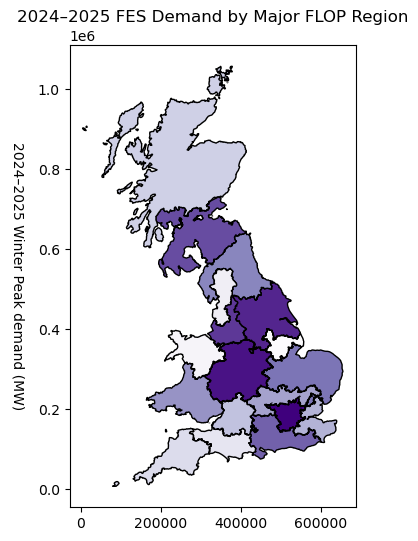

In [14]:
ax = demand_region_major_flop.plot(
    column="P(Gross)",
    cmap="Purples",
    legend=False,
    edgecolor="black"
)

# Get colorbar from the figure by searching for mappable
fig = ax.get_figure()
cbar = fig.axes[-1]   # last axis is the colorbar if it exists
cbar.set_ylabel("2024–2025 Winter Peak demand (MW)", rotation=270, labelpad=20)
ax.set_title("2024–2025 FES Demand by Major FLOP Region")
plt.show()

## Group by GSP Group

In [15]:
demand_region_major_flop.head()

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,14175.494211,2013.799336,2065.228,1.516,3.452,2510.823,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,5528.404094,480.559837,3495.84,205.942,0.469,1767.639,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,3323.620801,290.242999,3265.65,432.556,0.474,1431.918,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,3363.662607,208.781824,2526.342,78.99,1.17,1235.933,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1945.117259,46.144847,3373.952,6.692,0.467,700.089,_L,"MULTIPOLYGON (((347800.463 88920.721, 346449.7..."


In [16]:
# dno regions can be downloaded as a separate file or following the process above and dissolving on GSP Group

# groupby GSP Group
demand_region_group_flop = demand_region_major_flop.dissolve(by="GSP Group", aggfunc={"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})



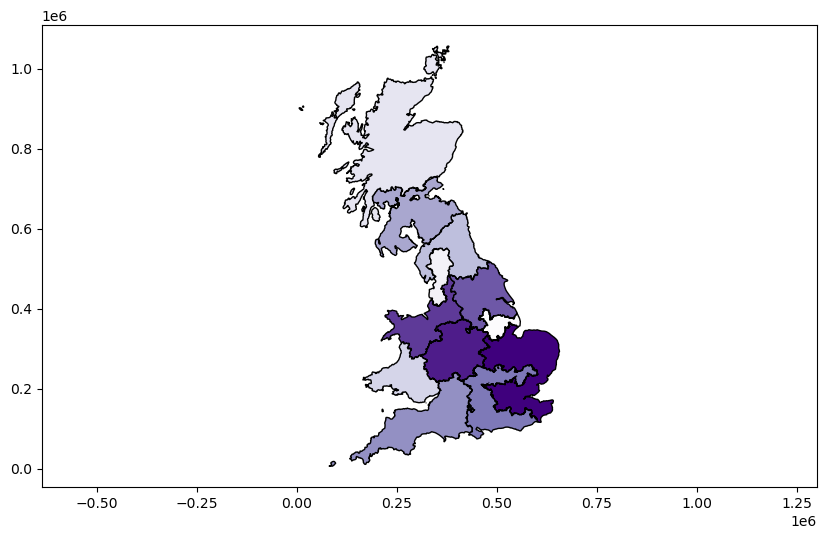

In [17]:
ax = demand_region_group_flop.plot(column="P(Gross)", cmap="Purples", legend=False, edgecolor="black")
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

### Embedded solar and wind generation

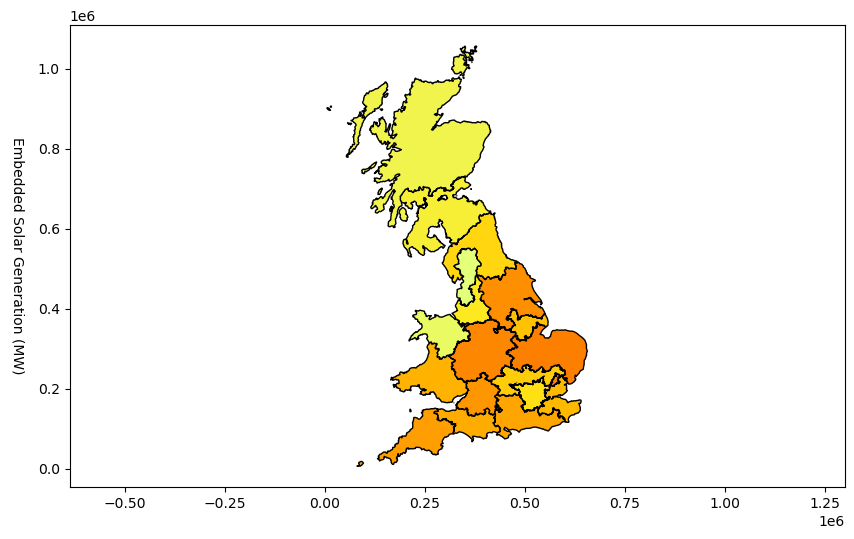

In [18]:
ax = demand_region_major_flop.plot(column="Embedded Solar", cmap="Wistia", legend=False, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[-1]
cbar.set_ylabel("Embedded Solar Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

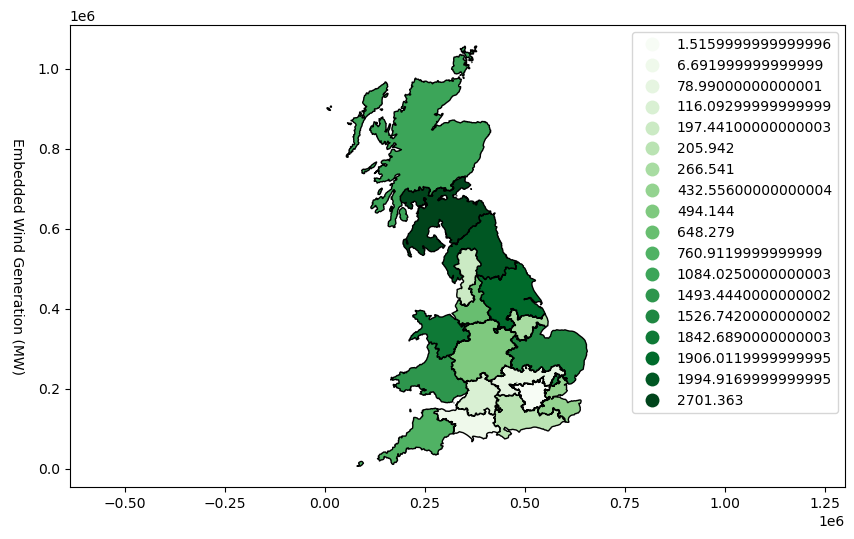

In [19]:
ax = demand_region_major_flop.plot(column="Embedded Wind", cmap="Greens", legend=True, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[-1]
cbar.set_ylabel("Embedded Wind Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

## Import generation data (Again)

In [20]:
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"), index_col=0)
print(gens_df.shape)
# convert to geopandas using longitude and latitude columns
gen_gdf = gpd.GeoDataFrame(gens_df, geometry=gpd.points_from_xy(gens_df.lon, gens_df.lat), crs="EPSG:4326")

# remove gilbraltar 
gen_gdf = gen_gdf[gen_gdf.lat >= 40]

# convert to british national grid
gen_gdf = gen_gdf.to_crs(epsg=27700)

(118, 6)


In [21]:
# assign large_gen_gdf to nearest polygon of major_FLOP_polygons
gen_gdf = gpd.sjoin_nearest(
    gen_gdf, 
    major_FLOP_polygons[["Major FLOP", "geometry"]], 
    how="left"
)
    
# drop the index column created by sjoin
gen_gdf = gen_gdf.drop(columns=["index_right"], errors="ignore")

In [22]:
gen_gdf.shape



(118, 8)

In [23]:
gen_gdf.head()

,Name,Fueltype,Technology,Capacity (MW),lat,lon,geometry,Major FLOP
id,,,,,,,,
37,Sloy,Hydro,Run-Of-River,153.0,56.2615,-4.7636,POINT (228923.845 711102.499),T
38,Foye,Hydro,Run-Of-River,320.0,57.2558,-4.4941,POINT (249643.853 821104.04),T
39,Ffes,Hydro,Run-Of-River,384.0,52.9808,-3.9686,POINT (267928.79 344418.088),M
40,Dino,Hydro,Run-Of-River,1728.0,53.1206,-4.1153,POINT (258539.759 360247.612),M
41,Crua,Hydro,Pumped Storage,440.0,56.4192,-5.0127,POINT (214268.534 729293.732),T


In [24]:
# group by type and major flop

gen_grouped = gen_gdf.groupby(["Major FLOP", "Fueltype"]).agg({'Capacity (MW)': 'sum'})
gen_grouped
#Putting this on the map


Capacity (MW)
Major FLOP Fueltype                    
A          Natural Gas           1267.0
B          Natural Gas           1465.0
           Wind                   400.0
C          Natural Gas           3990.0
           Solar                  378.3
           Wind                  1070.0
D          Natural Gas           1490.0
E          Natural Gas           1258.0
           Nuclear               5284.0
F          Natural Gas           1045.0
G          Natural Gas           1258.0
H          Natural Gas           4241.0
           Wind                   228.0
J          Natural Gas           4043.0
           Nuclear               1320.0
           Wind                  6959.8
K          Natural Gas           3633.0
           Wind                  1061.0
L          Natural Gas            236.0
M          Hydro                 2112.0
           Natural Gas           2015.0
           Wind                   576.0
N          Natural Gas           1855.0
           Wind                   254.0
P          Natural Gas           5462.0
           Solid Biomass         2718.0
           Wind                  1300.0
Q          Natural Gas            509.8
           Solid Biomass          299.0
           Wind                  5165.2
R          Nuclear               2676.0
S          Natural Gas           1008.0
           Nuclear               1370.0
           Wind                  3776.4
T          Hydro                  913.0
           Natural Gas           1653.0
           Wind                  4003.4

In [25]:
gen_grouped.xs('Wind', level='Fueltype')

,Capacity (MW)
Major FLOP,
B,400.0
C,1070.0
H,228.0
J,6959.8
K,1061.0
M,576.0
N,254.0
P,1300.0
Q,5165.2


In [26]:
large_wind_major_flop_polygons = gpd.GeoDataFrame(gen_grouped.xs('Wind', level='Fueltype').merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")


<Axes: >

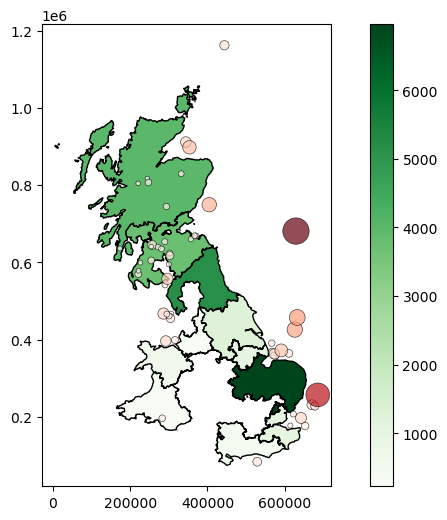

In [27]:
ax = large_wind_major_flop_polygons.plot(column="Capacity (MW)", cmap="Greens", legend=True, edgecolor="black")

# add points from gen_gdf with point size related to capacity
wind_gen = gen_gdf[gen_gdf["Fueltype"]=='Wind']
wind_gen.plot(
    ax=ax, 
    column="Capacity (MW)", 
    markersize=wind_gen["Capacity (MW)"] / 10,  # Scale factor to adjust size
    cmap="Reds",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5
)

In [28]:
# Create a new empty pandapower network
net = pp.create_empty_network()

# Extract list of Major FLOPs
zone_list = demand_region_major_flop["Major FLOP"].tolist()

# Dictionary to store mapping: zone name -> pandapower bus index
zone_to_bus = {}

# Create a bus for each Major FLOP
for zone in zone_list:
    bus_idx = pp.create_bus(net, vn_kv=400, name=f"Bus_{zone}") # 400 kV bus
    zone_to_bus[zone] = bus_idx # Store the bus index for each zone

zone_to_bus
bus_idx

17

In [29]:
from shapely.geometry import Point, LineString
import contextily as ctx
import matplotlib.pyplot as plt

# --- 1) Prepare the polygon GeoDataFrame and representative points ---
# Use the variable you have; you mentioned demand_region_major_flop
poly_gdf = demand_region_major_flop.copy()

# Normalise the Major FLOP name text to avoid subtle mismatches
name_col = "Major FLOP"
poly_gdf[name_col] = poly_gdf[name_col].astype(str).str.strip()

# Ensure geometry and CRS are correct (expect EPSG:27700 in your project)
if poly_gdf.crs is None:
    poly_gdf = poly_gdf.set_crs(epsg=27700)
elif poly_gdf.crs.to_epsg() != 27700:
    poly_gdf = poly_gdf.to_crs(epsg=27700)

# Create a representative point that is guaranteed to be inside the polygon
if 'rep_pt' not in poly_gdf.columns:
    poly_gdf = poly_gdf.copy()
    poly_gdf['rep_pt'] = poly_gdf.geometry.representative_point()


In [30]:
# --- 2) Build bus_gdf using the rep_pt and attach the pandapower bus index ---
# Build a GeoDataFrame of buses located inside the FLOP polygons
bus_gdf = gpd.GeoDataFrame(poly_gdf[[name_col]].copy(),
                           geometry=poly_gdf['rep_pt'].copy(),
                           crs=poly_gdf.crs)



# Map the pandapower bus index (zone_to_bus) to each GeoDataFrame row
# first normalise keys of zone_to_bus as strings (same normalisation applied above)
zone_to_bus_norm = {str(k).strip(): v for k, v in zone_to_bus.items()}
bus_gdf['pp_bus_index'] = bus_gdf[name_col].map(zone_to_bus_norm)

# Check for zones that didn't map to a pandapower bus
unmapped = bus_gdf[bus_gdf['pp_bus_index'].isna()][name_col].tolist()
if unmapped:
    print("Warning: these Major FLOP names were not found in zone_to_bus:", unmapped)

# Inspect
print("Created bus_gdf with", len(bus_gdf), "items. Example:")
display(bus_gdf.head())


Created bus_gdf with 18 items. Example:


,Major FLOP,geometry,pp_bus_index
0,A,POINT (518631.973 185916.885),0
1,B,POINT (504998.868 131829.028),1
2,C,POINT (578254.493 174391.247),2
3,D,POINT (467796.127 220949.655),3
4,E,POINT (354841.526 125641.932),4


In [31]:
# Add load (P(Gross)) to each bus
for zone in zone_list:
    p = float(demand_region_major_flop.loc[demand_region_major_flop["Major FLOP"] == zone, "P(Gross)"]) #select load value by zone
    pp.create_load(net, bus=zone_to_bus[zone], p_mw=p, q_mvar=0.0, name=f"Load_{zone}")


C:\Users\catz0911\AppData\Local\Temp\ipykernel_8696\2158893567.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(demand_region_major_flop.loc[demand_region_major_flop["Major FLOP"] == zone, "P(Gross)"]) #select load value by zone
C:\Users\catz0911\AppData\Local\Temp\ipykernel_8696\2158893567.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(demand_region_major_flop.loc[demand_region_major_flop["Major FLOP"] == zone, "P(Gross)"]) #select load value by zone
C:\Users\catz0911\AppData\Local\Temp\ipykernel_8696\2158893567.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(demand_region_major_flop.loc[demand_region_major_flop["Major FLOP"] == zone, "P(Gross)"]) #sel

In [32]:
#Add generators to each bus, from gen_grouped
for (zone, fueltype), row in gen_grouped.iterrows():
    capacity_mw = row['Capacity (MW)']
    pp.create_gen(net, bus=zone_to_bus[zone], p_mw=capacity_mw, vm_pu=1.0, name=f"Gen_{zone}_{fueltype}")

In [33]:
pp.create_ext_grid(net, bus=zone_to_bus["A"], vm_pu=1.0, name="Swing bus")

0

In [34]:
# Create lines between consecutive Major FLOPs
for i in range(len(zone_list)-1): 
    z1 = zone_list[i]
    z2 = zone_list[i+1]

    pp.create_line_from_parameters(
        net,
        from_bus=zone_to_bus[z1],
        to_bus=zone_to_bus[z2],
        length_km=50,           # simple assumption
        r_ohm_per_km=0.05,
        x_ohm_per_km=0.15,
        c_nf_per_km=10,
        max_i_ka=1.0
    )
print(net)

This pandapower network includes the following parameter tables:
   - bus (18 elements)
   - load (18 elements)
   - gen (37 elements)
   - ext_grid (1 element)
   - line (17 elements)


In [35]:
# 1) prepare polygon gdf and rep points
poly_gdf = demand_region_major_flop.copy()
NAME = "Major FLOP"                          # adjust only if your column name differs
poly_gdf[NAME] = poly_gdf[NAME].astype(str).str.strip()

# ensure polygons are in British National Grid (meters)
if poly_gdf.crs is None:
    poly_gdf = poly_gdf.set_crs(epsg=27700)
elif poly_gdf.crs.to_epsg() != 27700:
    poly_gdf = poly_gdf.to_crs(epsg=27700)

# representative point (guaranteed inside polygon)
poly_gdf['rep_pt'] = poly_gdf.geometry.representative_point()


In [36]:
# 2) make bus_gdf: one point per Major FLOP
bus_gdf = gpd.GeoDataFrame(poly_gdf[[NAME]].copy(),
                           geometry=poly_gdf['rep_pt'].copy(),
                           crs=poly_gdf.crs)

# attach pandapower bus index mapping if zone_to_bus exists
if 'zone_to_bus' in globals():
    zone_to_bus_norm = {str(k).strip(): v for k,v in zone_to_bus.items()}
    bus_gdf['pp_bus_index'] = bus_gdf[NAME].map(zone_to_bus_norm)
else:
    bus_gdf['pp_bus_index'] = np.nan

In [37]:
# 3) build MST to connect all bus points (Euclidean distances in EPSG:27700)
coords = [(pt.x, pt.y) for pt in bus_gdf.geometry]
n = len(coords)
# build complete weighted graph
G = nx.Graph()
for i in range(n):
    G.add_node(i)
for i in range(n):
    xi, yi = coords[i]
    for j in range(i+1, n):
        xj, yj = coords[j]
        d = ((xi-xj)**2 + (yi-yj)**2)**0.5
        G.add_edge(i, j, weight=d)

# minimum spanning tree edges
mst = nx.minimum_spanning_tree(G, weight='weight')
mst_edges = list(mst.edges())

# create LineString geometries for MST edges
line_geoms = []
meta = []
for i, j in mst_edges:
    line_geoms.append(LineString([coords[i], coords[j]]))
    meta.append({ 'from': bus_gdf.iloc[i][NAME], 'to': bus_gdf.iloc[j][NAME], 
                  'from_idx': i, 'to_idx': j })

lines_gdf = gpd.GeoDataFrame(meta, geometry=line_geoms, crs=bus_gdf.crs)
lines_gdf.head()


,from,to,from_idx,to_idx,geometry
0,A,B,0,1,"LINESTRING (518631.973 185916.885, 504998.868 ..."
1,A,C,0,2,"LINESTRING (518631.973 185916.885, 578254.493 ..."
2,A,D,0,3,"LINESTRING (518631.973 185916.885, 467796.127 ..."
3,A,J,0,8,"LINESTRING (518631.973 185916.885, 554704.796 ..."
4,D,G,3,6,"LINESTRING (467796.127 220949.655, 392243.087 ..."


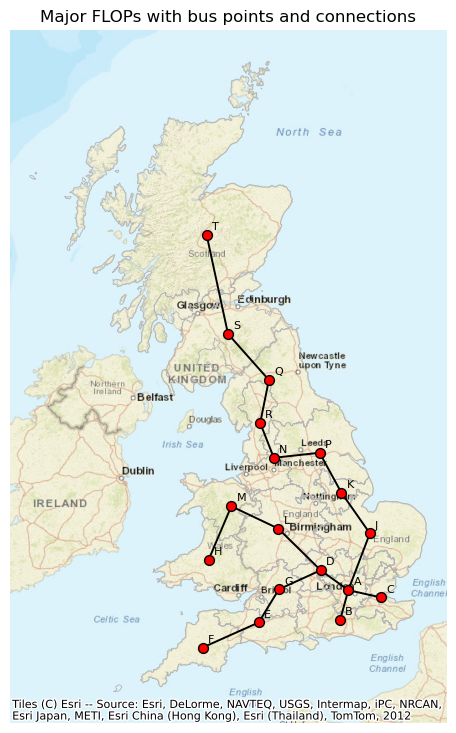

In [38]:
# 4) quick plot (reproject to EPSG:3857 for basemap)
poly_plot  = poly_gdf.to_crs(epsg=3857)
bus_plot   = bus_gdf.to_crs(epsg=3857)
lines_plot = lines_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11,9))
poly_plot.plot(ax=ax, facecolor='none', edgecolor='0.7', linewidth=0.6, zorder=1)
lines_plot.plot(ax=ax, color='black', linewidth=1.4, zorder=2)

# size by Pd_MW if available else constant
if 'Pd_MW' in bus_plot.columns:
    sizes = (bus_plot['Pd_MW'].fillna(0) + 0.1) ** 0.8 * 40
    bus_plot.plot(ax=ax, markersize=sizes, color='red', edgecolor='k', zorder=3)
else:
    bus_plot.plot(ax=ax, color='red', markersize=50, edgecolor='k', zorder=3)

# === 🔥 Add bus name labels here ===
for i, row in bus_plot.iterrows():
    ax.text(row.geometry.x + 15000, row.geometry.y + 15000,
            str(row['Major FLOP']),
            fontsize=8, color='black', zorder=4)

ax.set_axis_off()
plt.title("Major FLOPs with bus points and connections")
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldStreetMap) 
plt.show()


In [41]:
# Diagnostic: show ext_grid, buses and gens in the current net
import pandas as pd
print("=== net summary ===")
print("buses:", len(net.bus))
print("lines:", len(net.res_line))
print("loads:", len(net.load))
print("gens:", len(net.gen))
print("ext_grids:", len(net.ext_grid))
print()

print("net.bus head:")
print(net.bus.head())

print("\nnet.ext_grid table:")
print(net.ext_grid if len(net.ext_grid) else "No ext_grid rows")

print("\nnet.gen table (show slack column if any):")
print(net.gen[['bus','p_mw','slack']] if len(net.gen) else "No gens")

print("\nCheck ext_grid 'in_service' and referenced buses present:")
if len(net.ext_grid):
    for _, r in net.ext_grid.iterrows():
        b = r['bus']
        print("ext_grid at bus", b, "in_service=", bool(r.get('in_service', True)), "bus_exists=", b in net.bus.index)



=== net summary ===
buses: 18
lines: 17
loads: 18
gens: 37
ext_grids: 1

net.bus head:
    name  vn_kv type  zone  in_service  \
0  Bus_A  400.0    b  None        True   
1  Bus_B  400.0    b  None        True   
2  Bus_C  400.0    b  None        True   
3  Bus_D  400.0    b  None        True   
4  Bus_E  400.0    b  None        True   

                                            geo  
0  {"coordinates": [0.0, 0.0], "type": "Point"}  
1  {"coordinates": [1.0, 0.0], "type": "Point"}  
2  {"coordinates": [2.0, 0.0], "type": "Point"}  
3  {"coordinates": [3.0, 0.0], "type": "Point"}  
4  {"coordinates": [4.0, 0.0], "type": "Point"}  

net.ext_grid table:
        name  bus  vm_pu  va_degree  slack_weight  in_service  controllable
0  Swing bus    0    1.0        0.0           1.0        True         False

net.gen table (show slack column if any):
    bus    p_mw  slack
0     0  1267.0  False
1     1  1465.0  False
2     1   400.0  False
3     2  3990.0  False
4     2   378.3  False
5     

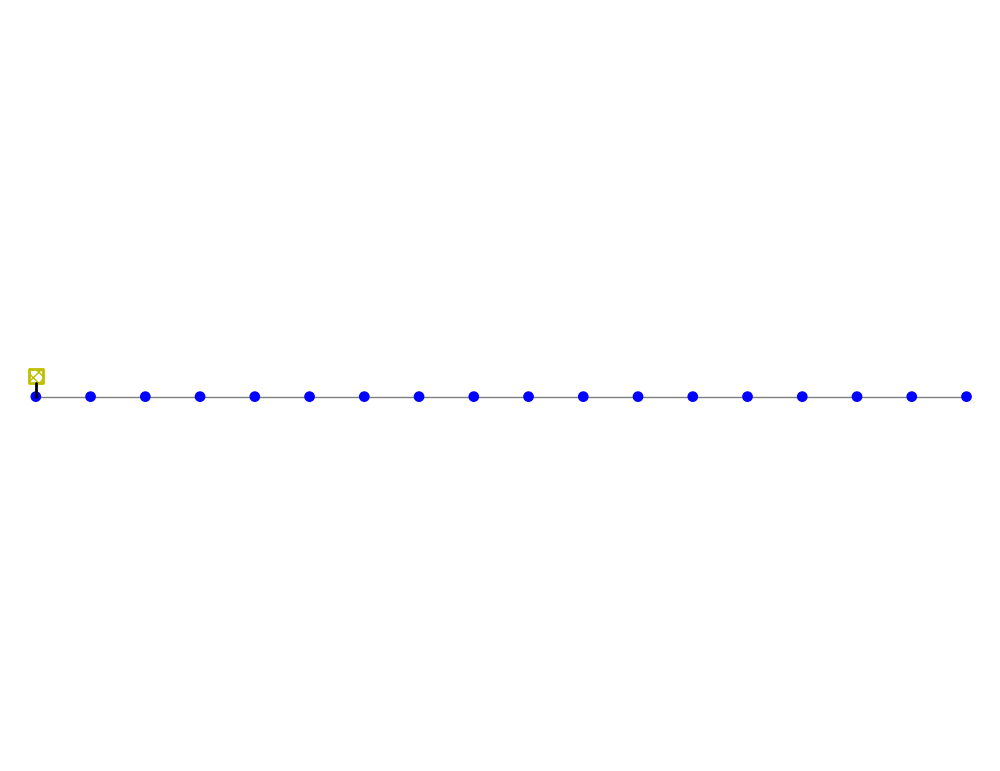

    vm_pu   va_degree          p_mw       q_mvar
0     1.0    0.000000  -3827.174844   886.942344
1     1.0  -11.131472   3663.404094 -1597.522891
2     1.0  -10.901422  -2114.679199   613.491318
3     1.0  -16.888466   1873.662607  -716.039558
4     1.0  -17.168920  -4596.882741   959.849438
5     1.0  -30.759284   1410.873757 -1278.913975
6     1.0  -39.297451   1676.266619  -804.652615
7     1.0  -42.560940   -566.615957   102.745853
8     1.0  -47.419751  -7050.375910   326.763572
9     1.0  -72.248025  -3788.046400 -3990.140087
10    1.0 -104.573358  10625.536352 -6876.965163
11    1.0 -100.490946  -3328.372113   974.261610
12    1.0 -106.210327   6619.144678 -3009.909732
13    1.0  -91.256614   -336.806937 -1339.411482
14    1.0  -75.974507  -1465.959816  -698.875741
15    1.0  -64.076651   -899.612185  -449.034144
16    1.0  -54.207010    115.680274  -710.897807
17    1.0  -43.351664  -3730.460812   874.310077


In [42]:
pp.runpp(net)  
simple_plot(net)
print(net.res_bus)


~From Leo~

In [ ]:
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# coords in lon/lat
coords = net.bus_geodata
xs = coords["longitude"].astype(float)
ys = coords["latitude"].astype(float)

plt.figure(figsize=(8, 12))
# plot lines
for _, line in net.line.iterrows():
    fb = int(line["from_bus"]); tb = int(line["to_bus"])
    lon1 = float(coords.loc[fb, "longitude"]); lat1 = float(coords.loc[fb, "latitude"])
    lon2 = float(coords.loc[tb, "longitude"]); lat2 = float(coords.loc[tb, "latitude"])
    plt.plot([lon1, lon2], [lat1, lat2], color="tab:gray", linewidth=1.5, alpha=0.9)

# plot buses
plt.scatter(xs, ys, s=50, color="red", edgecolor="black", zorder=3)

# labels
for idx, row in coords.iterrows():
    plt.text(row["longitude"] + 0.03, row["latitude"] + 0.03, net.bus.loc[idx, "name"], fontsize=8)

plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Network geographic layout (no basemap)")

plt.show()
